# fog_scored — 가중치 기반 쿨링포그 설치 우선순위 산출

**프로젝트:** HeatGuardAI — 서울시 폭염 대응 쿨링포그 설치 추천 시스템

**목적:** GMM 군집화 없이, **Robust z-score 가중합** 방식으로 GlobalScore를 산출합니다.

**파이프라인:**
1. 데이터 로드 · 검증
2. Robust z-score 계산 → 클리핑 → NDVI 부호 반전
3. 정책 가중치 적용 → GlobalScore 산출 → 순위 매기기
4. GlobalScore 정규화 (0~100)
5. 구(Gu)별 분석 · 시각화
6. 행정동/구별 상위 셀 추출 (최소 거리 필터링)
7. 클러스터별 분리 · GEE 시각화 (선택)
8. 최종 CSV 저장

**입력:** `data/processed/heatguard_cell_feature_scored_clean.csv`
**출력:** `final_fog_score.csv`, `heatguard_ranking_data_cluster_1.csv`, `heatguard_ranking_data_cluster_2.csv`

## 0. 라이브러리 · 설정

In [1]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# 한글 폰트 설정 (Mac → AppleGothic, Windows → Malgun Gothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ── 전역 설정 ──
DATA_PATH   = "../data_processed/processed/merged/heatguard_cell_feature_scored_clean.csv"
OUTPUT_DIR  = "../data_processed/processed/merged/"

FEATURE_COLS = [
    "suhii_score",
    "apparent_temp_score",
    "bus_flow_score",
    "ndvi_score",
    "vulnerable_score",
]

# 정책 가중치 (합계 = 1.0)
WEIGHTS = {
    "vulnerable_score":     0.246,
    "suhii_score":          0.227,
    "apparent_temp_score":  0.215,
    "ndvi_score":           0.170,
    "bus_flow_score":       0.142,
}

CLUSTER_NAME_MAP = {
    "자연 완화형 관리 지역":       "자연완화",
    "폭염 고온 핵심 개입 지역":    "고온핵심",
    "유동인구 체감온도 고위험 지역": "녹지부족",
}

## 0-1. 헬퍼 함수 정의

In [3]:
def robust_z(series: pd.Series) -> pd.Series:
    """Median / MAD 기반 Robust z-score를 계산합니다."""
    med = series.median()
    mad = (series - med).abs().median()
    if mad == 0:
        return pd.Series(0.0, index=series.index)
    return (series - med) / (mad * 1.4826)


def haversine_m(lat1, lon1, lat2, lon2):
    """두 위경도 좌표 사이의 거리를 미터 단위로 계산합니다."""
    R = 6_371_000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def select_top_cells(df_in, min_dist=200, top_n=5, rank_col="Dong_Rank"):
    """GlobalScore 순으로 정렬된 df에서 최소 min_dist(m) 간격으로 top_n개를 선택합니다."""
    selected = []
    for _, row in df_in.iterrows():
        lat, lon = row["center_lat"], row["center_lon"]
        too_close = any(
            haversine_m(lat, lon, s["center_lat"], s["center_lon"]) < min_dist
            for s in selected
        )
        if not too_close:
            row_dict = row.to_dict()
            row_dict[rank_col] = len(selected) + 1
            selected.append(row_dict)
        if len(selected) >= top_n:
            break
    return pd.DataFrame(selected)

## 1. 데이터 로드

In [4]:
df = pd.read_csv(DATA_PATH)

# 필수 컬럼 검증
required = FEATURE_COLS + ["cell_id", "center_lat", "center_lon"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"필수 컬럼 누락: {missing}"

# 결측값 제거
mask = df[FEATURE_COLS].notna().all(axis=1)
df = df[mask].copy()

print(f"행 수: {len(df):,}")
print(f"피처: {FEATURE_COLS}")
df.head()

행 수: 87,936
피처: ['suhii_score', 'apparent_temp_score', 'bus_flow_score', 'ndvi_score', 'vulnerable_score']


,cell_id,center_lat,center_lon,gu_name,dong_name,suhii,suhii_score,apparent_temp,apparent_temp_score,bus_flow_score,ndvi,ndvi_score,vulnerable_score,cluster,cluster_name
0,1411415045163,37.552140,126.789567,강서구,공항동,1.501585,0.511384,30.55,0.593023,0.658269,0.345653,0.518903,0.449954,1,폭염 고온 핵심 개입 지역
1,1411415045164,37.552852,126.789567,강서구,공항동,3.212939,0.564623,30.55,0.593023,0.657479,0.132720,0.362348,0.449954,2,유동인구 체감온도 고위험 지역
2,1411415045165,37.553564,126.789567,강서구,공항동,4.440008,0.602797,30.55,0.593023,0.656581,0.097017,0.336099,0.449954,1,폭염 고온 핵심 개입 지역
3,1411425045158,37.548579,126.790465,강서구,공항동,-4.832725,0.314329,30.51,0.585271,0.678467,0.615040,0.716965,0.449954,2,유동인구 체감온도 고위험 지역
4,1411425045159,37.549291,126.790465,강서구,공항동,-4.828229,0.314469,30.51,0.585271,0.678324,0.619014,0.719887,0.449954,2,유동인구 체감온도 고위험 지역


## 2. Robust z-score 계산 및 GlobalScore 산출

1. 각 피처에 대해 **Robust z-score** (median/MAD 기반) 계산
2. **[-3, +3]** 구간으로 클리핑 (극단값 영향 완화)
3. NDVI는 녹지가 많을수록 위험이 낮으므로 **부호 반전**
4. 가중합 → **GlobalScore** 산출

In [5]:
# ── 1) Robust z-score 계산 ──
z_df = df[FEATURE_COLS].apply(robust_z)

# ── 2) 클리핑 [-3, +3] ──
z_df = z_df.clip(-3, 3)

# ── 3) NDVI 부호 반전 (녹지 많음 = 위험 낮음) ──
z_df["ndvi_score"] *= -1

# z-score를 원본 df에 저장
for c in FEATURE_COLS:
    df[f"{c}_z"] = z_df[c].values

# ── 4) 가중합 → GlobalScore ──
df["GlobalScore"] = sum(z_df[c] * WEIGHTS[c] for c in WEIGHTS)
df["Rank"] = df["GlobalScore"].rank(ascending=False, method="min").astype(int)

# ── 5) 0~100 정규화 ──
gs_min, gs_max = df["GlobalScore"].min(), df["GlobalScore"].max()
df["GlobalScore_norm"] = (df["GlobalScore"] - gs_min) / (gs_max - gs_min) * 100

print(df[["cell_id", "GlobalScore", "GlobalScore_norm", "Rank"]].sort_values("Rank").head(10))

             cell_id  GlobalScore  GlobalScore_norm  Rank
75552  1414915045071     1.650607        100.000000     1
74639  1414885045072     1.634669         99.582288     2
74944  1414895045072     1.628991         99.433478     3
84500  1415415045141     1.624352         99.311906     4
84381  1415405045141     1.607393         98.867433     5
75551  1414915045070     1.605060         98.806302     6
82974  1415295045087     1.604474         98.790950     7
75249  1414905045072     1.594722         98.535371     8
75248  1414905045071     1.581049         98.177026     9
84265  1415395045142     1.556616         97.536698    10


## 3. 구(Gu)별 GlobalScore 분석

구별 평균 GlobalScore를 계산하고, 어떤 피처가 높은 점수에 기여하는지 분석합니다.

In [6]:
# ── 구별 평균 GlobalScore ──
gu_mean = (
    df.groupby("gu_name", as_index=False)["GlobalScore"]
    .mean()
    .sort_values("GlobalScore", ascending=False)
)

# ── 구별 피처 기여도 (z_df와 df는 같은 인덱스이므로 gu_name만 붙여 사용, join 시 컬럼 중복 방지) ──
z_with_gu = z_df.copy()
z_with_gu["gu_name"] = df["gu_name"].values
gu_feat_mean = z_with_gu.groupby("gu_name")[list(WEIGHTS.keys())].mean()
gu_contrib = gu_feat_mean.mul(pd.Series(WEIGHTS), axis=1)
gu_contrib["GlobalScore_mean"] = gu_contrib.sum(axis=1)

# 상위 기여 피처 추출
def explain_row(row):
    top = row[list(WEIGHTS.keys())].sort_values(ascending=False).head(3)
    return " + ".join(f"{f}({v:.3f})" for f, v in top.items())

gu_contrib["TopReasons"] = gu_contrib.apply(explain_row, axis=1)

pd.set_option("display.max_colwidth", None)
gu_contrib.sort_values("GlobalScore_mean", ascending=False)[["GlobalScore_mean", "TopReasons"]].head(10)

,GlobalScore_mean,TopReasons
gu_name,,
강동구,0.511033,apparent_temp_score(0.282) + suhii_score(0.153) + vulnerable_score(0.143)
송파구,0.374729,apparent_temp_score(0.272) + suhii_score(0.089) + vulnerable_score(0.036)
강서구,0.330827,vulnerable_score(0.240) + apparent_temp_score(0.136) + ndvi_score(0.027)
동대문구,0.290240,suhii_score(0.114) + vulnerable_score(0.100) + ndvi_score(0.056)
동작구,0.186438,vulnerable_score(0.091) + suhii_score(0.060) + apparent_temp_score(0.041)
마포구,0.184524,suhii_score(0.125) + apparent_temp_score(0.074) + ndvi_score(0.040)
양천구,0.178495,vulnerable_score(0.107) + apparent_temp_score(0.034) + bus_flow_score(0.034)
강남구,0.124443,apparent_temp_score(0.147) + vulnerable_score(0.057) + bus_flow_score(0.014)
은평구,0.107519,vulnerable_score(0.364) + bus_flow_score(0.018) + suhii_score(-0.002)


## 4. 시각화

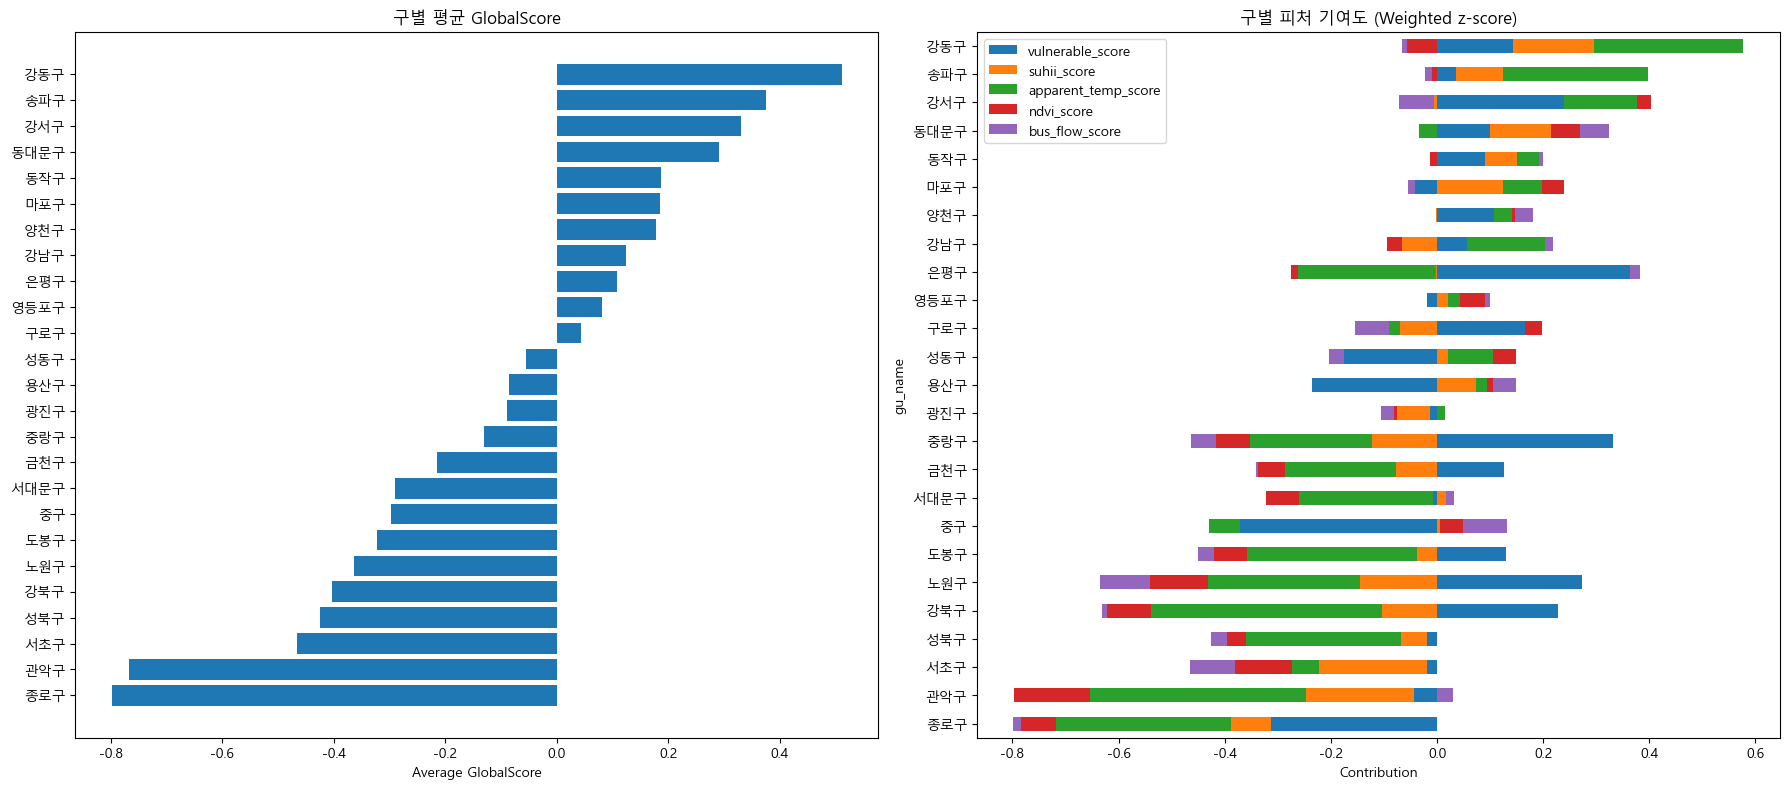

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── 왼쪽: 구별 평균 GlobalScore 막대 ──
axes[0].barh(gu_mean["gu_name"], gu_mean["GlobalScore"])
axes[0].invert_yaxis()
axes[0].set_title("구별 평균 GlobalScore")
axes[0].set_xlabel("Average GlobalScore")

# ── 오른쪽: 피처 기여도 누적 막대 ──
gu_sorted = gu_contrib.sort_values("GlobalScore_mean", ascending=True)
gu_sorted[list(WEIGHTS.keys())].plot(kind="barh", stacked=True, ax=axes[1])
axes[1].set_title("구별 피처 기여도 (Weighted z-score)")
axes[1].set_xlabel("Contribution")

plt.tight_layout()
plt.show()

## 5. 행정동/구별 상위 셀 추출 (최소 200m 간격)

같은 행정동/구 내에서 너무 가까운 셀이 중복 추천되지 않도록,
**200m 최소 간격 필터링**을 적용하여 상위 셀을 선택합니다.

In [8]:
df_sorted = df.sort_values("GlobalScore", ascending=False)

# ── 행정동별 상위 5개 (200m 간격) ──
df_fog_dong = (
    df_sorted
    .groupby(["gu_name", "dong_name"], group_keys=False)
    .apply(lambda g: select_top_cells(g, min_dist=200, top_n=5, rank_col="Dong_Rank"))
)
print(f"행정동 기준: {len(df_fog_dong)}개 셀")

# ── 클러스터별 분리 ──
df_sorted_c1 = df_sorted[df_sorted["cluster"] == 1]
df_sorted_c2 = df_sorted[df_sorted["cluster"] == 2]

# ── 구별 상위 셀 추출 (클러스터별) ──
df_gu_c1 = (
    df_sorted_c1
    .groupby("gu_name", group_keys=False)
    .apply(lambda g: select_top_cells(g, min_dist=200, top_n=7, rank_col="Gu_Rank"))
)

df_gu_c2 = (
    df_sorted_c2
    .groupby("gu_name", group_keys=False)
    .apply(lambda g: select_top_cells(g, min_dist=200, top_n=3, rank_col="Gu_Rank"))
)

print(f"Cluster 1 (구별): {len(df_gu_c1)}개 셀")
print(f"Cluster 2 (구별): {len(df_gu_c2)}개 셀")

행정동 기준: 2286개 셀
Cluster 1 (구별): 175개 셀
Cluster 2 (구별): 72개 셀


C:\Users\User\AppData\Local\Temp\ipykernel_13712\180631089.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: select_top_cells(g, min_dist=200, top_n=5, rank_col="Dong_Rank"))
C:\Users\User\AppData\Local\Temp\ipykernel_13712\180631089.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: select_top_cells(g, min_dist=200, top_n=7, rank_col="Gu_Rank"))
C:\Users\User\AppData\L

## 6. Google Earth Engine 지도 시각화 (선택)

> GEE 인증이 필요합니다. 필요 없으면 이 섹션을 건너뛰세요.

In [ ]:
# ── GEE 시각화 (필요시 주석 해제) ──
# import ee, geemap
#
# ee.Authenticate()
# ee.Initialize(project="gee-project-483401")
#
# def df_to_ee_points(df_in, lat_col="center_lat", lon_col="center_lon"):
#     features = [
#         ee.Feature(ee.Geometry.Point([row[lon_col], row[lat_col]]), row.to_dict())
#         for _, row in df_in.iterrows()
#     ]
#     return ee.FeatureCollection(features)
#
# Map = geemap.Map(center=[37.5665, 126.9780], zoom=11)
# if len(df_gu_c1) > 0:
#     Map.addLayer(df_to_ee_points(df_gu_c1), {"color": "red",    "pointSize": 3}, "Cluster 1")
# if len(df_gu_c2) > 0:
#     Map.addLayer(df_to_ee_points(df_gu_c2), {"color": "yellow", "pointSize": 3}, "Cluster 2")
# Map

## 7. 최종 결과 저장

In [ ]:
# ── 클러스터 라벨 축약 ──
for target_df in [df_fog_dong, df_gu_c1, df_gu_c2]:
    if "cluster_name" in target_df.columns:
        target_df["cluster_name"] = target_df["cluster_name"].replace(CLUSTER_NAME_MAP)

# ── CSV 저장 ──
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_fog_dong.to_csv(f"{OUTPUT_DIR}/final_fog_score.csv", index=False, encoding="utf-8-sig")
print(f"Saved: {OUTPUT_DIR}/final_fog_score.csv")

df_gu_c1.to_csv(f"{OUTPUT_DIR}/heatguard_ranking_data_cluster_1.csv", index=False, encoding="utf-8-sig")
print(f"Saved: {OUTPUT_DIR}/heatguard_ranking_data_cluster_1.csv")

df_gu_c2.to_csv(f"{OUTPUT_DIR}/heatguard_ranking_data_cluster_2.csv", index=False, encoding="utf-8-sig")
print(f"Saved: {OUTPUT_DIR}/heatguard_ranking_data_cluster_2.csv")

Saved: ../data_processed/processed/merged//final_fog_score.csv
Saved: ../data_processed/processed/merged//heatguard_ranking_data_cluster_1.csv
Saved: ../data_processed/processed/merged//heatguard_ranking_data_cluster_2.csv


In [10]:
df = pd.read_csv("../data_processed/processed/merged//final_fog_score.csv")
df.head()

,cell_id,center_lat,center_lon,gu_name,dong_name,suhii,suhii_score,apparent_temp,apparent_temp_score,bus_flow_score,...,cluster_name,suhii_score_z,apparent_temp_score_z,bus_flow_score_z,ndvi_score_z,vulnerable_score_z,GlobalScore,Rank,GlobalScore_norm,Dong_Rank
0,1414425045064,37.481601,127.059960,강남구,개포1동,5.759410,0.643842,30.95,0.670543,0.754785,...,폭염 고온 핵심 개입 지역,0.032292,2.82443,0.906889,1.136826,-0.371573,0.845214,4650,78.892412,1
1,1414455045063,37.480888,127.062655,강남구,개포1동,4.484442,0.604179,30.95,0.670543,0.784815,...,폭염 고온 핵심 개입 지역,-0.261398,2.82443,1.221307,0.747010,-0.371573,0.756925,6563,76.578551,2
2,1414395045059,37.478036,127.057265,강남구,개포1동,2.867719,0.553884,31.26,0.730620,0.744676,...,폭염 고온 핵심 개입 지역,-0.633812,3.00000,0.801046,0.236386,-0.371573,0.563652,12250,71.513276,3
3,1414475045061,37.479462,127.064451,강남구,개포1동,3.602762,0.576750,31.98,0.870155,0.729513,...,폭염 고온 핵심 개입 지역,-0.464494,3.00000,0.642288,-0.010318,-0.371573,0.537604,13240,70.830613,4
4,1414435045061,37.479462,127.060858,강남구,개포1동,1.195229,0.501854,30.95,0.670543,0.731017,...,폭염 고온 핵심 개입 지역,-1.019072,2.82443,0.658032,0.287103,-0.371573,0.426764,18232,67.925756,5
